# Notebook 04: Forecasting, Uncertainty Quantification & XAI

## 1. Overview
In this final stage, we perform inference using the "Champion" LSTM model. We transition from predicting annual variations ($\Delta K_t$) to projecting long-term mortality levels ($K_t$) and life expectancy.

## 2. Methodology
- **Recursive Forecasting**: Using predicted variations to reconstruct future mortality indices step-by-step up to 2050.
- **Monte Carlo Dropout**: Activating dropout layers during inference to generate stochastic trajectories and fan charts.
- **Back-Transformation**: Converting latent factors back into death rates ($m_x$) and survival probabilities ($q_x$).
- **Explainability (XAI)**: Analyzing feature importance to understand cluster-wide influences.

## 4.1: Environment Setup and Asset Loading

In [1]:
import os
import sys
import logging
import warnings

# 1. SILENCE SYSTEM WARNINGS (Before importing heavy libraries)
# Silence urllib3/LibreSSL warnings
warnings.filterwarnings("ignore", category=UserWarning, module="urllib3")
# Silence Keras optimizer/variable loading warnings
warnings.filterwarnings("ignore", message="Skipping variable loading for optimizer")

# Silence TensorFlow C++ info/warnings (Metal/NUMA info)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

# Silence TensorFlow Python-level warnings
tf.get_logger().setLevel(logging.ERROR)

# 2. Setup Style and Paths
sys.path.append('../src/')
from style_config import set_style
COUNTRIES_DICT = set_style()
FIGURES_DIR = "../reports/figures/"
MODELS_DIR = "../models/"

# 3. Load serialized assets from Notebook 03
model_path = os.path.join(MODELS_DIR, "mortality_lstm_champion.keras")
scaler_path = os.path.join(MODELS_DIR, "data_scaler.pkl")

if not os.path.exists(model_path) or not os.path.exists(scaler_path):
    raise FileNotFoundError("Assets not found. Please run Notebook 03 serialization cell first.")

# Loading the "Champion" model
# We set compile=False because we only need the model for inference (forecasting),
# which avoids the optimizer mismatch warnings entirely.
mortality_model = tf.keras.models.load_model(model_path, compile=False)
scaler = joblib.load(scaler_path)

# 4. Load processed factors to get the "starting point" (last known year: 2020)
DATA_PATH = "../data/processed/benchmarking_factors.npz"
with np.load(DATA_PATH, allow_pickle=True) as data:
    kt_global = data['kt_common']        
    kt_local_matrix = data['kt_specific_matrix'] 
    years = data['years']
    country_codes = data['countries']

# Reconstruct the full features (Levels)
full_features = np.column_stack([kt_global, kt_local_matrix])
last_year = years[-1]

print(f"--- Environment Ready ---")
print(f"Model loaded successfully: {mortality_model.name}")
print(f"Base Year for Forecast: {last_year}")
print(f"Target: Recursive forecasting up to 2050")

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


--- Environment Ready ---
Model loaded successfully: functional_1
Base Year for Forecast: 2020
Target: Recursive forecasting up to 2050


## 4.2: Stochastic Recursive Forecasting (Monte Carlo Dropout)

In [2]:
def forecast_with_uncertainty(model, initial_sequence, n_steps, n_simulations=500):
    """
    Performs recursive forecasting with Monte Carlo Dropout and progress monitoring.
    """
    n_features = initial_sequence.shape[-1]
    all_sims_diffs = np.zeros((n_simulations, n_steps, n_features))
    
    print(f"Starting {n_simulations} Monte Carlo simulations...")
    
    # 1. Prepare input tensor shape once to avoid repeated warnings
    # We ensure the tensor is explicitly cast to float32
    
    for sim in range(n_simulations):
        current_seq = initial_sequence.copy()
        
        for step in range(n_steps):
            # Convert to tensor and add batch dimension to satisfy Keras expectations
            input_tensor = tf.convert_to_tensor(current_seq[np.newaxis, ...], dtype=tf.float32)
            
            # training=True keeps Dropout active during inference
            pred_diff_scaled = model(input_tensor, training=True)
            
            # Extract and reshape
            pred_val = pred_diff_scaled.numpy().reshape(n_features)
            
            # Store the predicted difference
            all_sims_diffs[sim, step, :] = pred_val
            
            # Update the sequence for the next recursive step
            current_seq = np.roll(current_seq, -1, axis=0)
            current_seq[-1] = pred_val
            
        # Progress Print every 10%
        if (sim + 1) % (n_simulations // 10) == 0:
            print(f"Progress: {((sim + 1) / n_simulations) * 100:.0f}% complete...")
            
    return all_sims_diffs

# 1. Prepare starting sequence
diff_features = np.diff(full_features, axis=0)
diff_scaled = scaler.transform(diff_features)
initial_sequence = diff_scaled[-10:] 

# 2. Run the Forecast
N_YEARS_AHEAD = 30
simulated_diffs_scaled = forecast_with_uncertainty(
    mortality_model, 
    initial_sequence, 
    n_steps=N_YEARS_AHEAD, 
    n_simulations=1000 
)

print(f"\n--- Simulations Complete ---")
print(f"Shape: {simulated_diffs_scaled.shape} (Simulations, Years, Factors)")

Starting 1000 Monte Carlo simulations...
Progress: 10% complete...
Progress: 20% complete...
Progress: 30% complete...
Progress: 40% complete...
Progress: 50% complete...
Progress: 60% complete...
Progress: 70% complete...
Progress: 80% complete...
Progress: 90% complete...
Progress: 100% complete...

--- Simulations Complete ---
Shape: (1000, 30, 7) (Simulations, Years, Factors)


## 4.3: Reconstructing Levels from Differences (Stochastic Integration)

In [3]:
# 1. Define feature count and Reshape
# n_features is 7 (1 Global + 6 Specific)
n_features = simulated_diffs_scaled.shape[2] 

# Flatten to (1000*30, 7) to apply the inverse scaling
flat_diffs = simulated_diffs_scaled.reshape(-1, n_features)
flat_diffs_real = scaler.inverse_transform(flat_diffs)

# Reshape back to (Simulations, Years, Features)
sims_diffs_real = flat_diffs_real.reshape(1000, N_YEARS_AHEAD, n_features)

# 2. Cumulative Sum (Integration)
# Starting point: the last known levels in 2020 (from Notebook 02)
last_level_2020 = full_features[-1]

# Create storage for levels: (1000, 31, 7) -> includes 2020 as year 0
sims_levels = np.zeros((1000, N_YEARS_AHEAD + 1, n_features))
sims_levels[:, 0, :] = last_level_2020

# Progressively add the predicted differences to the previous level
for t in range(1, N_YEARS_AHEAD + 1):
    sims_levels[:, t, :] = sims_levels[:, t-1, :] + sims_diffs_real[:, t-1, :]

# 3. Calculate Percentiles for the Common Factor (Feature 0)
forecast_years = np.arange(last_year, last_year + N_YEARS_AHEAD + 1)
kt_common_sims = sims_levels[:, :, 0] # Extract only the Global Trend (Li-Lee Kt)

median_kt = np.percentile(kt_common_sims, 50, axis=0)
lower_95 = np.percentile(kt_common_sims, 2.5, axis=0)
upper_95 = np.percentile(kt_common_sims, 97.5, axis=0)
lower_80 = np.percentile(kt_common_sims, 10, axis=0)
upper_80 = np.percentile(kt_common_sims, 90, axis=0)

print(f"--- Levels Reconstructed ---")
print(f"Forecast Horizon: {last_year} -> {forecast_years[-1]}")
print(f"Median Kt in 2050: {median_kt[-1]:.2f}")
print(f"95% Confidence Interval in 2050: [{lower_95[-1]:.2f}, {upper_95[-1]:.2f}]")

--- Levels Reconstructed ---
Forecast Horizon: 2020 -> 2050
Median Kt in 2050: -123.68
95% Confidence Interval in 2050: [-125.26, -121.79]


## 4.4: Fan Chart Visualization of Global Mortality Trend ($K_t$)

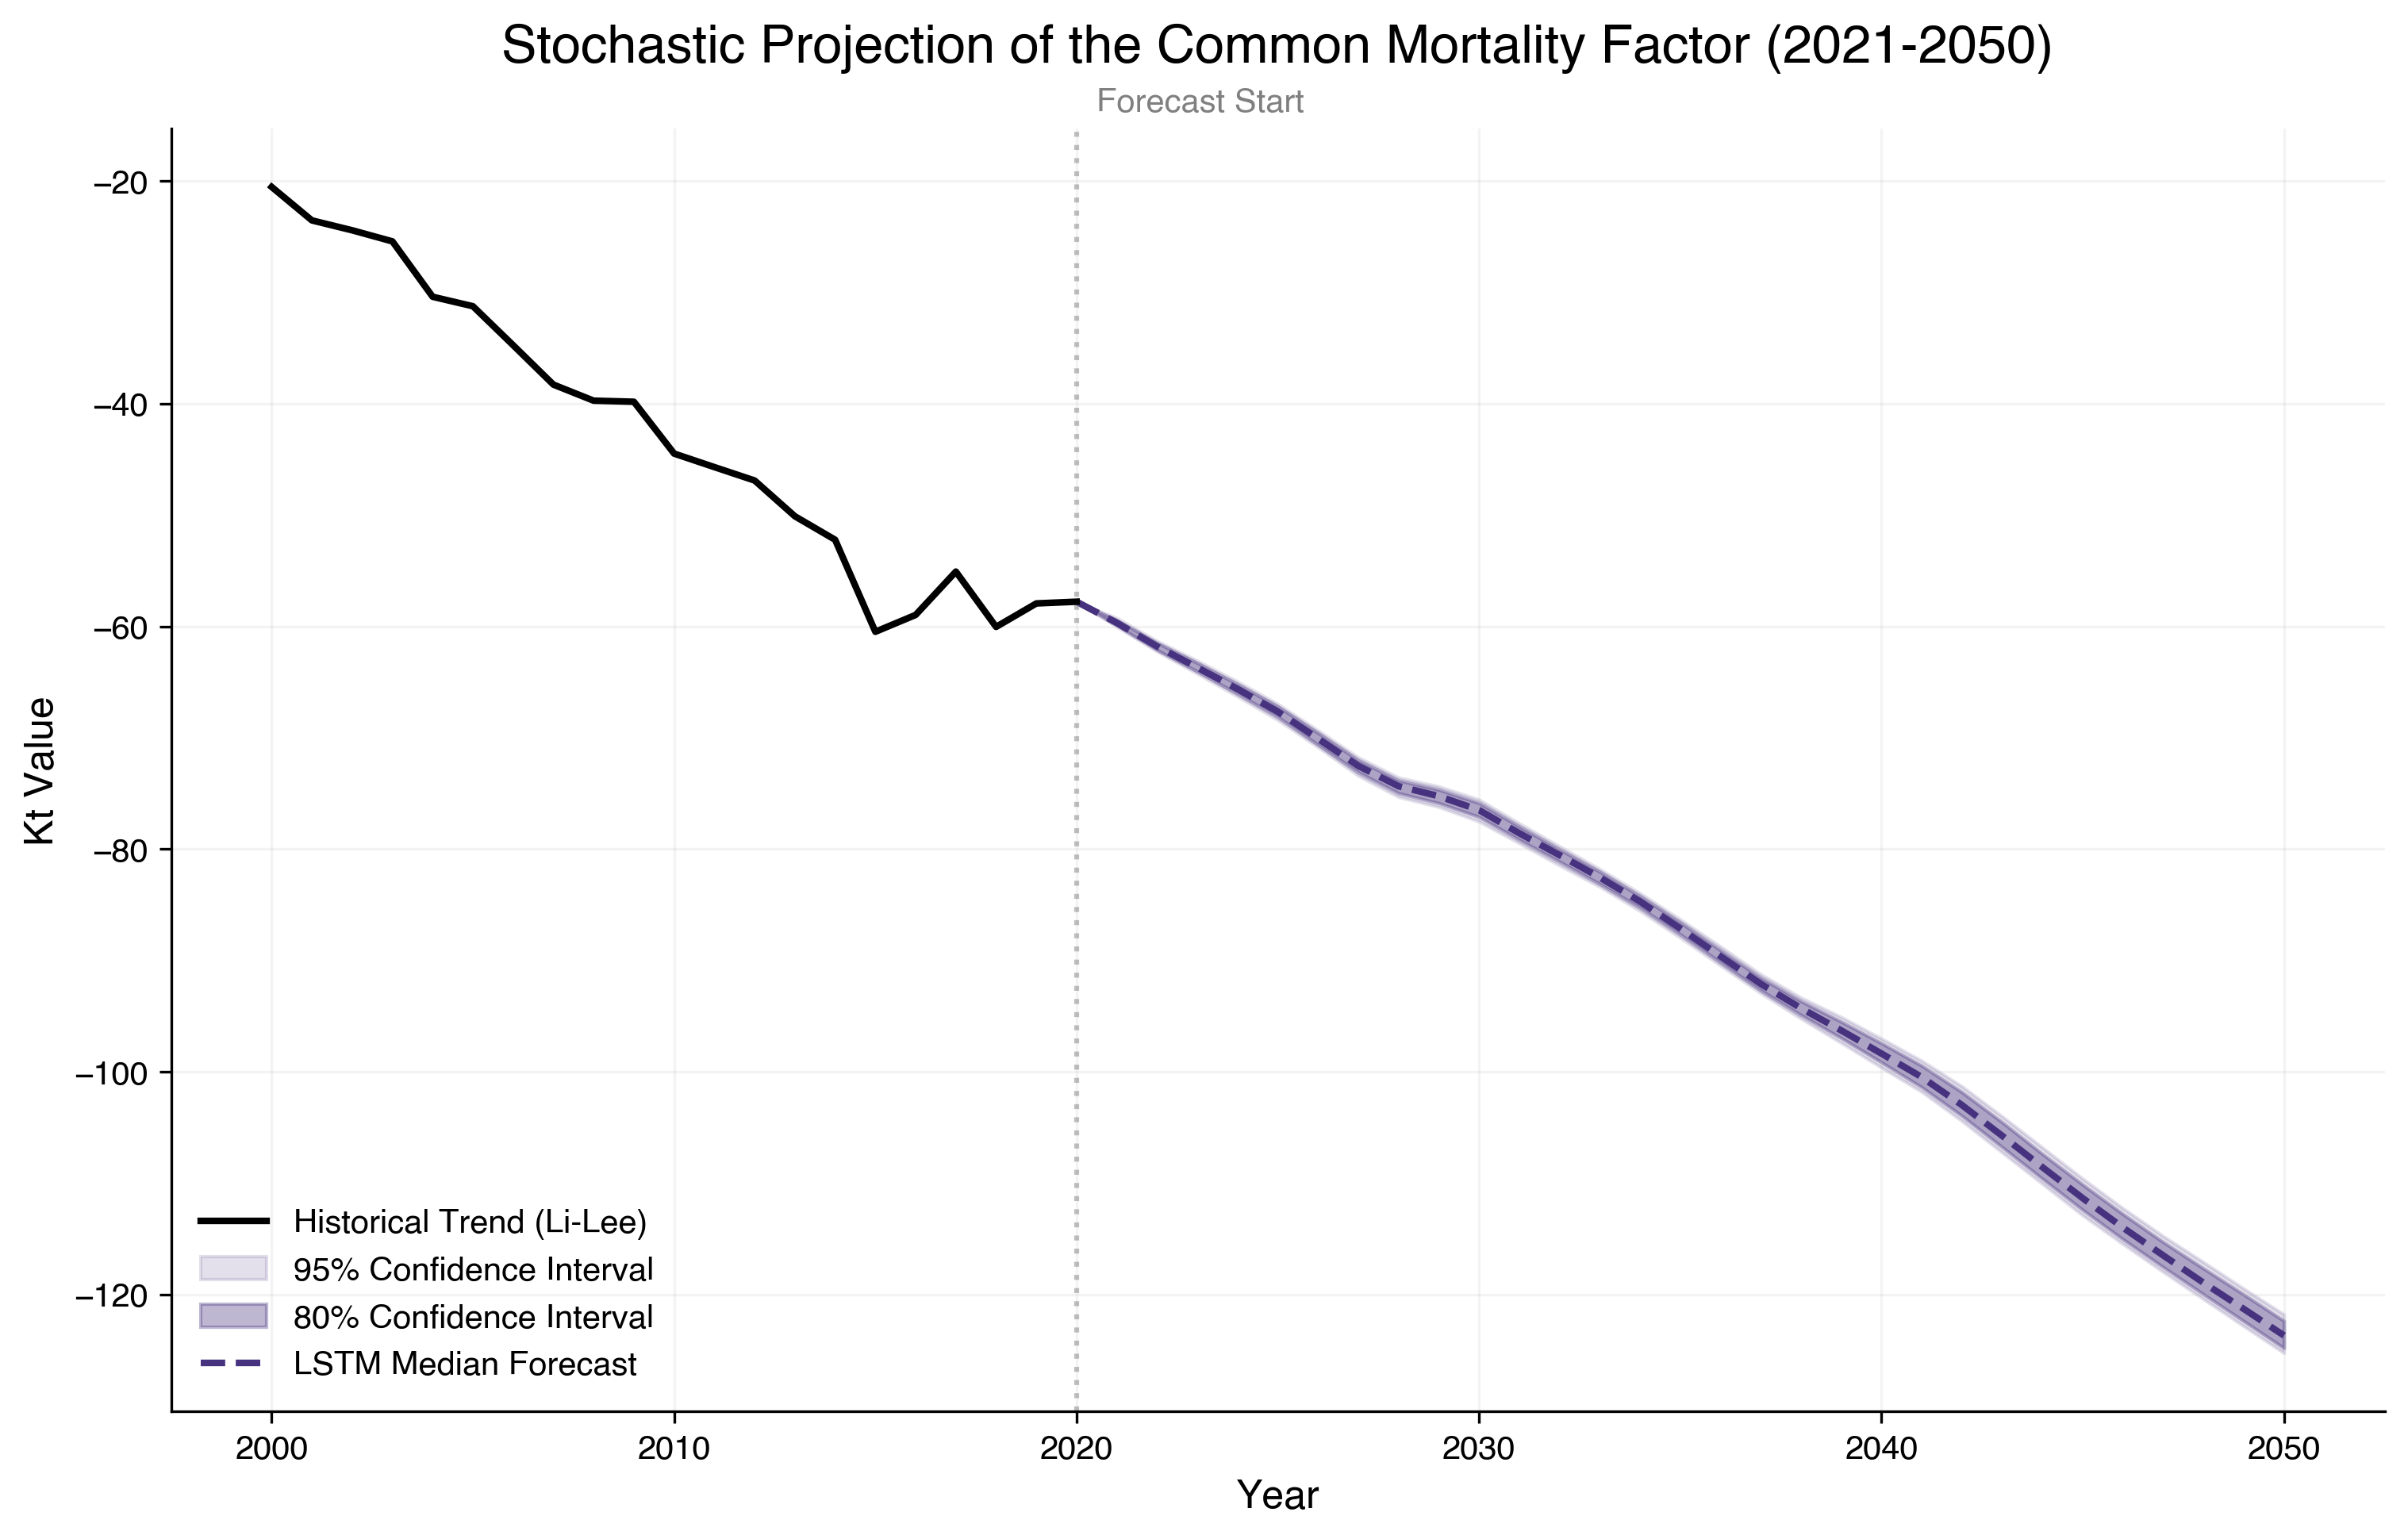

--- Fan Chart (Fig 09) successfully generated and saved ---
Path: ../reports/figures/fig09_kt_stochastic_forecast.png


In [4]:
import seaborn as sns

# 1. Retrieve the color palette and constants
# COUNTRIES_DICT was returned by set_style() in Cell 4.1
current_palette = sns.color_palette("viridis", len(COUNTRIES_DICT))
main_color = current_palette[0] # Using the first color for the common trend

# 2. Setup Plot (Size and DPI are handled by rcParams in style_config)
fig, ax = plt.subplots()

# 3. Plot Historical Data (Focus on 2000-2020 for recent context)
mask_hist = (years >= 2000)
ax.plot(years[mask_hist], kt_global[mask_hist], 
        color='black', 
        label='Historical Trend (Li-Lee)', 
        linewidth=2, 
        zorder=5)

# 4. Plot Stochastic Forecast (Fan Chart)
# 95% Confidence Interval (Lightest shade)
ax.fill_between(forecast_years, lower_95, upper_95, 
                color=main_color, 
                alpha=0.15, 
                label='95% Confidence Interval')

# 80% Confidence Interval (Medium shade)
ax.fill_between(forecast_years, lower_80, upper_80, 
                color=main_color, 
                alpha=0.35, 
                label='80% Confidence Interval')

# Median Projection (Bold dashed line)
ax.plot(forecast_years, median_kt, 
        color=main_color, 
        linestyle='--', 
        linewidth=2, 
        label='LSTM Median Forecast')

# 5. Annotations and Labels
ax.set_title("Stochastic Projection of the Common Mortality Factor (2021-2050)")
ax.set_xlabel("Year")
ax.set_ylabel("Kt Value")

# Transition vertical line at the end of observed data (2020)
ax.axvline(x=2020, color='grey', linestyle=':', alpha=0.5)
ax.text(2020.5, ax.get_ylim()[1] * 0.9, 'Forecast Start', 
        fontsize=10, color='grey', style='italic')

ax.legend(loc='lower left', frameon=False)

# 6. Export Figure for arXiv Paper
save_path = f"{FIGURES_DIR}fig09_kt_stochastic_forecast.png"
plt.savefig(save_path)
plt.show()

print(f"--- Fan Chart (Fig 09) successfully generated and saved ---")
print(f"Path: {save_path}")

## 4.5: Stochastic Life Expectancy Projections (Full Cluster)

In [5]:
# 1. Load the comprehensive Actuarial Parameters saved from Notebook 02
ACTUARIAL_DATA = "../data/processed/li_lee_parameters.npz"
with np.load(ACTUARIAL_DATA, allow_pickle=True) as data:
    Ax_matrix = data['Ax']          # Baseline age profiles (Ages x Countries)
    Bx_common = data['Bx_common']    # Common age sensitivity (shared across cluster)

# 2. Actuarial Function for Life Expectancy at Birth (e0)
def calculate_life_expectancy(log_mx):
    """
    Computes life expectancy (e0) using the standard Life Table method.
    Standard actuarial approximation for qx and mid-period adjustment.
    """
    mx = np.exp(log_mx)
    qx = mx / (1 + 0.5 * mx)
    qx[-1] = 1.0  
    px = 1.0 - qx
    lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
    ex = np.sum(lx) - 0.5 
    return ex

# 3. Global Projection Engine
# We store results for all countries in a dictionary for cross-country analysis
all_e0_results = {}

print(f"Starting stochastic projections for all {len(COUNTRIES_DICT)} countries...")

for idx, (code, name) in enumerate(COUNTRIES_DICT.items()):
    # Get country-specific baseline (ax)
    ax_country = Ax_matrix[:, idx]
    
    # Storage for 1,000 simulations over the forecast horizon
    e0_sims = np.zeros((1000, N_YEARS_AHEAD + 1))
    
    for s in range(1000):
        for t in range(N_YEARS_AHEAD + 1):
            # Li-Lee Reconstruction: ln(mx) = ax_i + Bx_common * Kt_stochastic
            current_kt = kt_common_sims[s, t]
            log_mx_recon = ax_country + Bx_common * current_kt
            e0_sims[s, t] = calculate_life_expectancy(log_mx_recon)
    
    # Statistical reduction (Median, 95% Confidence Interval)
    all_e0_results[code] = {
        'median': np.percentile(e0_sims, 50, axis=0),
        'lower': np.percentile(e0_sims, 2.5, axis=0),
        'upper': np.percentile(e0_sims, 97.5, axis=0),
        'sims': e0_sims, # Optional: keep raw sims for custom shocks analysis
        'name': name
    }
    
    # Live Reporting
    m_2020 = all_e0_results[code]['median'][0]
    m_2050 = all_e0_results[code]['median'][-1]
    print(f"-> {name}: 2020={m_2020:.2f} | 2050={m_2050:.2f} (Gain: {m_2050-m_2020:+.2f} yrs)")

print("\n--- Full Cluster Projection Complete ---")

Starting stochastic projections for all 6 countries...
-> Switzerland: 2020=81.71 | 2050=85.19 (Gain: +3.48 yrs)
-> Sweden: 2020=81.71 | 2050=85.14 (Gain: +3.44 yrs)
-> Norway: 2020=81.53 | 2050=85.05 (Gain: +3.52 yrs)
-> West Germany: 2020=80.37 | 2050=84.29 (Gain: +3.93 yrs)
-> Netherlands: 2020=81.30 | 2050=84.89 (Gain: +3.60 yrs)
-> Japan: 2020=81.72 | 2050=85.20 (Gain: +3.48 yrs)

--- Full Cluster Projection Complete ---


## 4.6: Multi-Country Life Expectancy Visualization

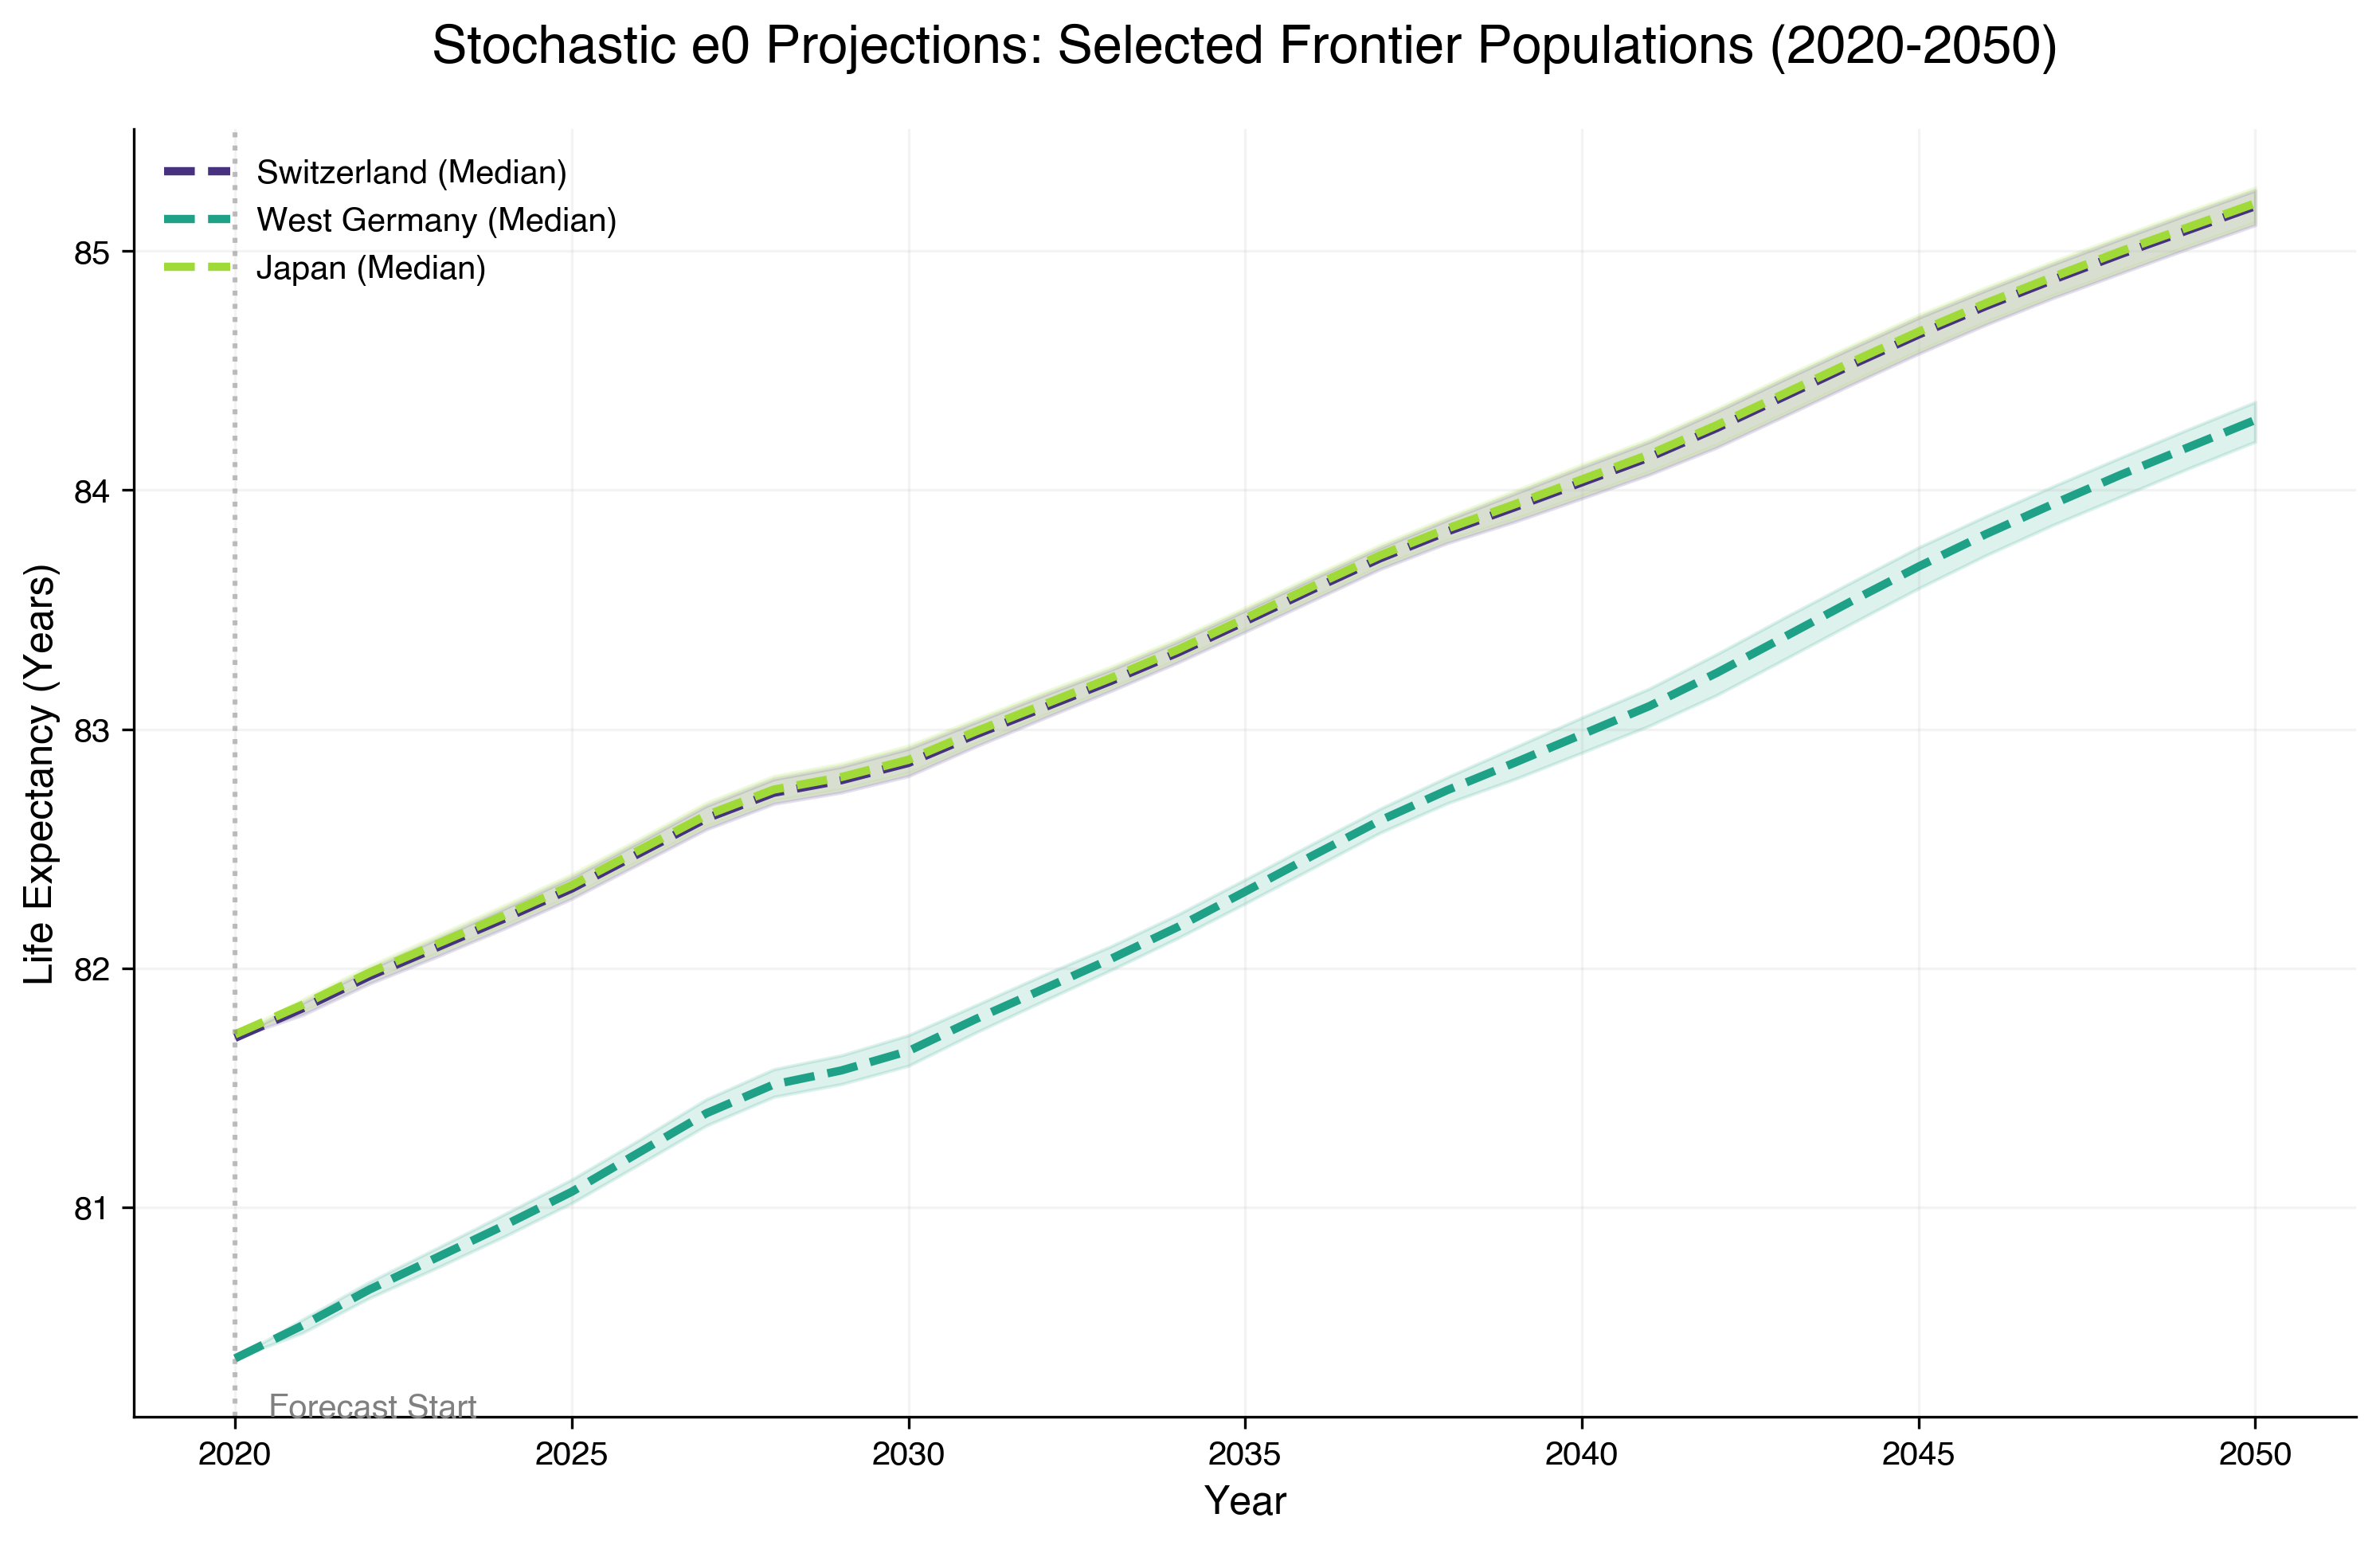

--- Figure 10 (Comparison) saved: ../reports/figures/fig10_multi_country_e0_forecast.png ---


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selection for visualization
# We'll plot Switzerland as primary, and Japan as the benchmark leader
selected_countries = ['CHE', 'JPN', 'DEUTW'] 
full_palette = sns.color_palette("viridis", len(COUNTRIES_DICT))

fig, ax = plt.subplots()

for i, code in enumerate(COUNTRIES_DICT.keys()):
    if code not in selected_countries:
        continue
    
    # Get pre-calculated results from Cell 4.5
    res = all_e0_results[code]
    color = full_palette[i]
    
    # Plot Median Forecast
    ax.plot(forecast_years, res['median'], 
            label=f"{res['name']} (Median)", 
            color=color, linewidth=2.5, linestyle='--')
    
    # Plot 95% Confidence Interval (Fan)
    ax.fill_between(forecast_years, res['lower'], res['upper'], 
                    color=color, alpha=0.15)
    
    # Optional: Plot Historical data (last 10 years for context)
    # We can retrieve this from the first year of our projection back to 2010
    # To keep the plot clean, we focus mainly on the forecast
    
# 2. Add 2020 Transition Marker
ax.axvline(x=2020, color='grey', linestyle=':', alpha=0.5)
ax.text(2020.5, ax.get_ylim()[0], 'Forecast Start', 
        fontsize=10, color='grey', style='italic')

# 3. Aesthetics
ax.set_title("Stochastic e0 Projections: Selected Frontier Populations (2020-2050)")
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy (Years)")
ax.legend(loc='upper left', frameon=False, ncol=1)

# 4. Export
save_path = f"{FIGURES_DIR}fig10_multi_country_e0_forecast.png"
plt.savefig(save_path)
plt.show()

print(f"--- Figure 10 (Comparison) saved: {save_path} ---")

## 4.7: Explainable AI (XAI): Temporal Feature Importance Analysis

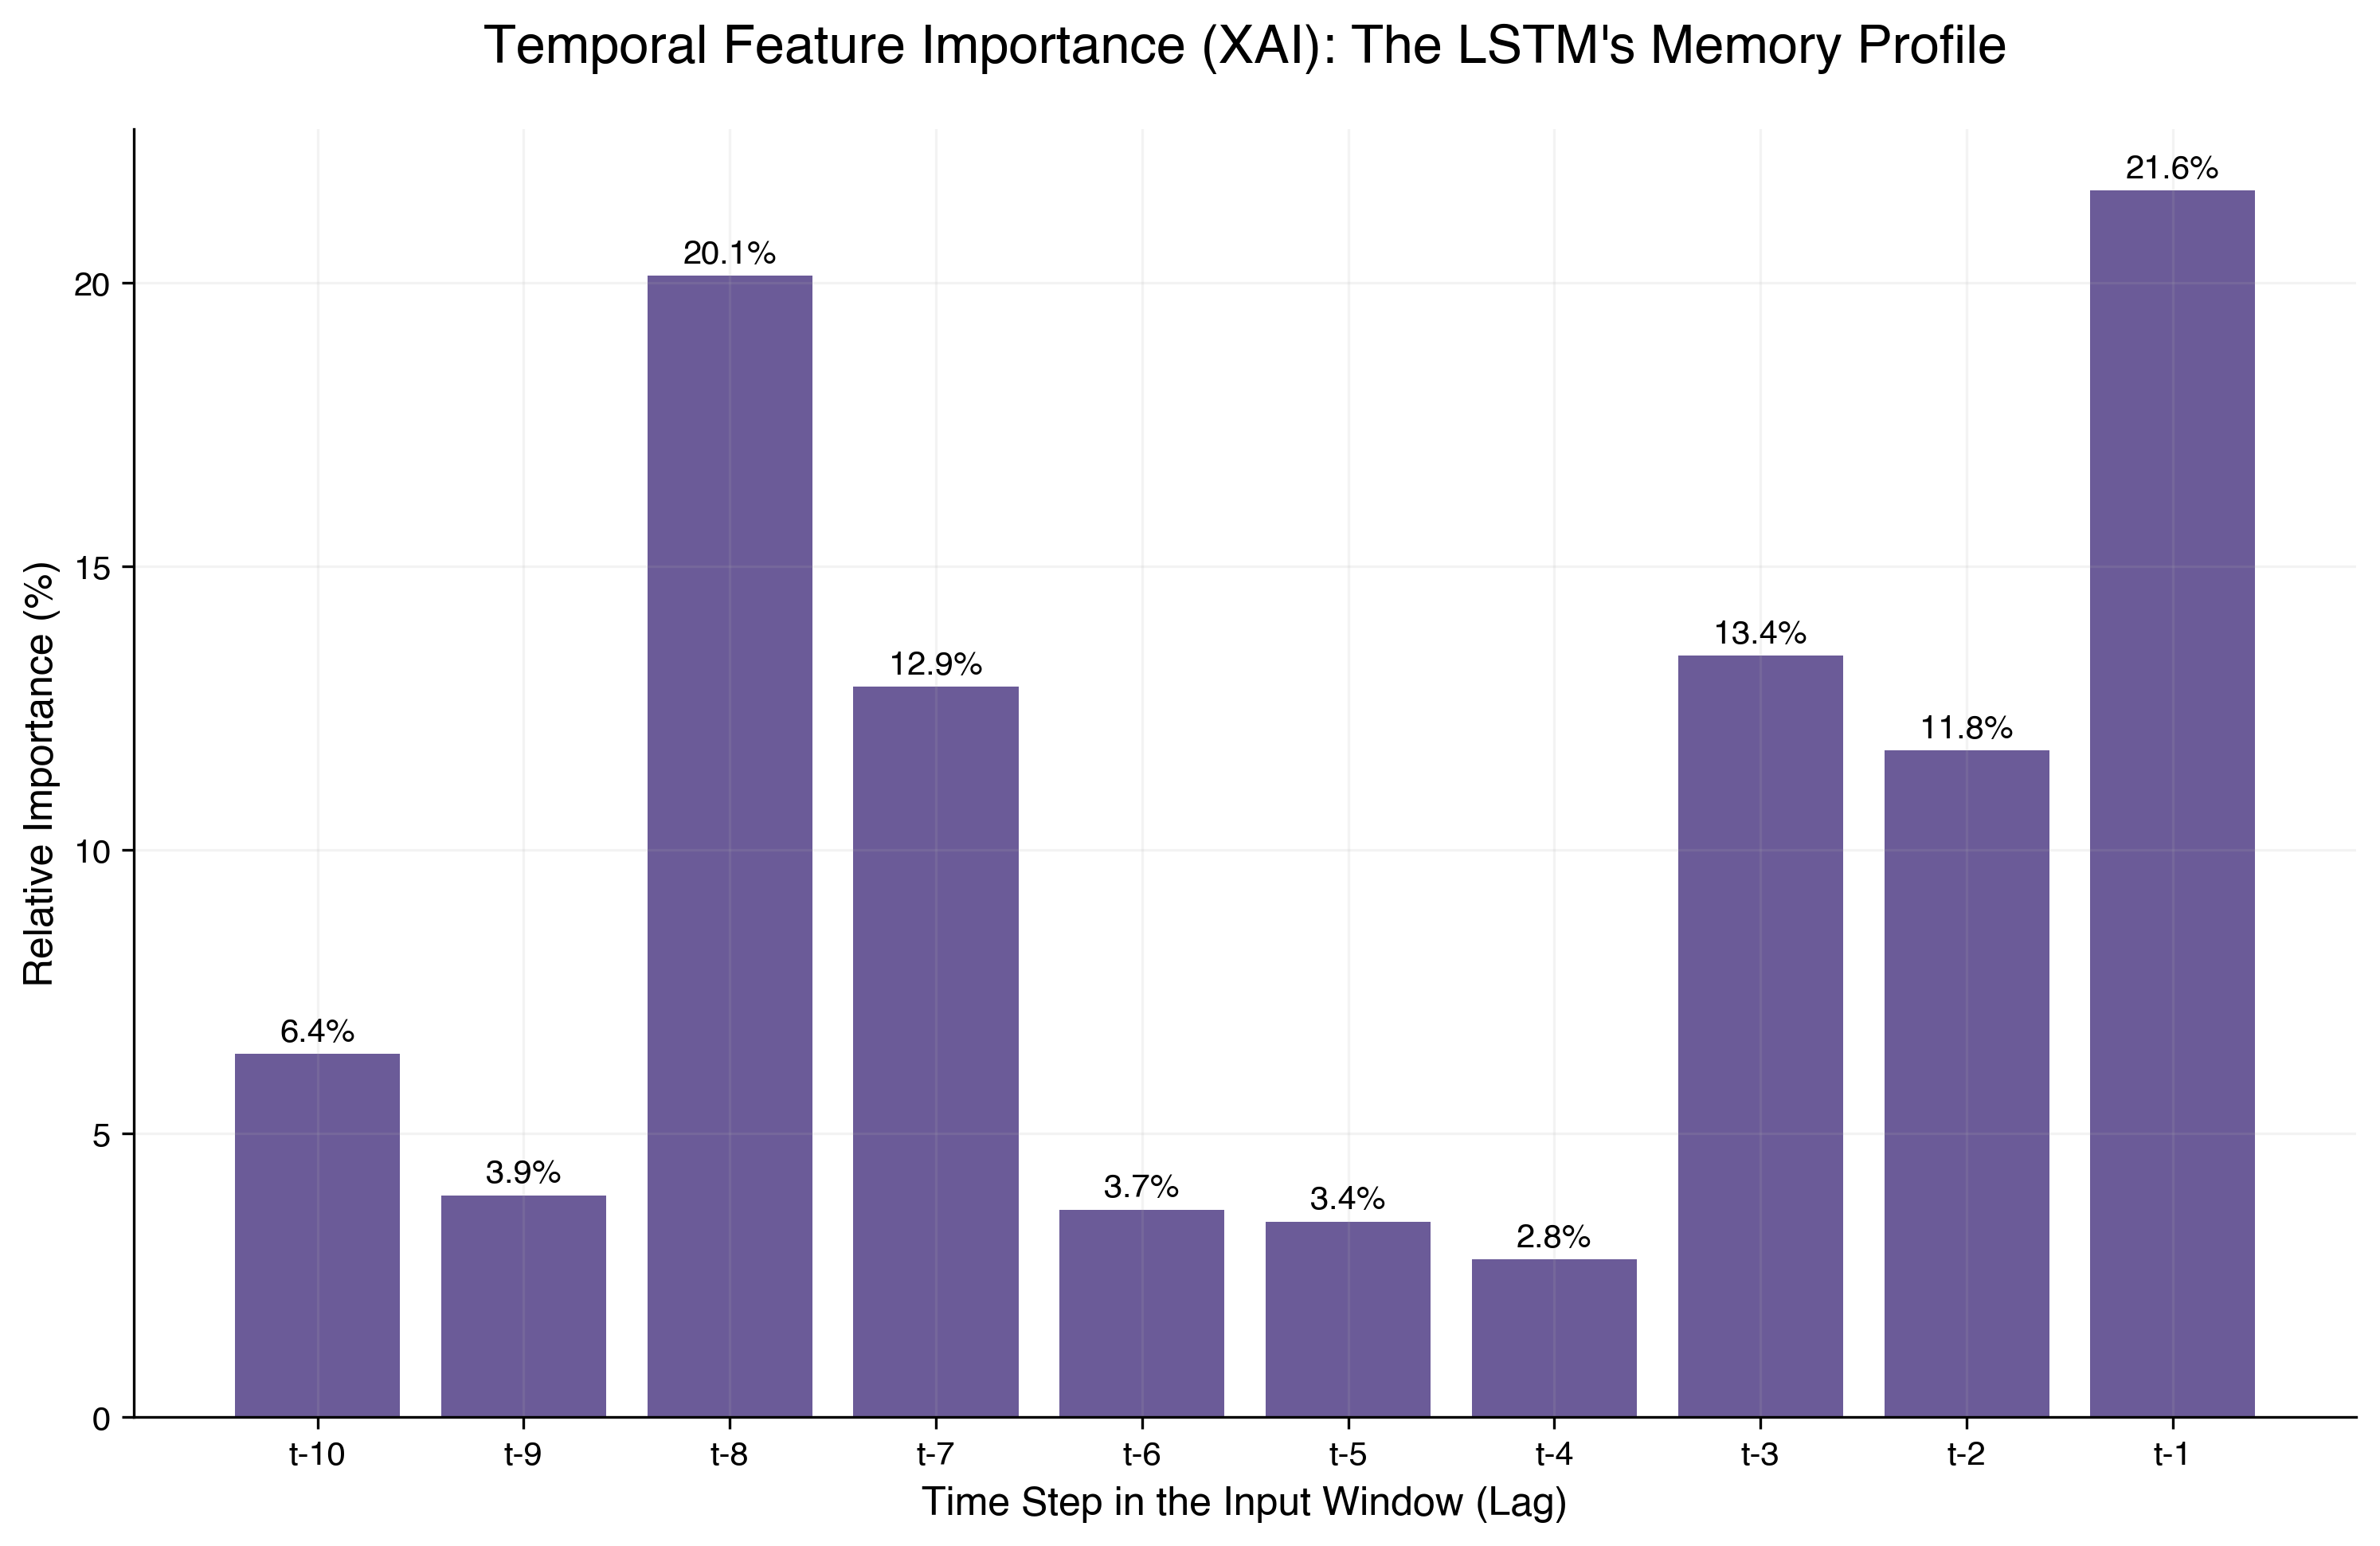

--- XAI Analysis Complete ---
Figure 11 saved to: ../reports/figures/fig11_xai_temporal_importance.png


In [7]:
import tensorflow as tf

# 1. Prepare the reference input (The last 10 years of real data: 2011-2020)
# 'initial_sequence' was defined in Cell 2 as the last 10 scaled differences
# We add the batch dimension to make it compatible with the model input
sample_tensor = tf.convert_to_tensor(initial_sequence[np.newaxis, ...], dtype=tf.float32)

# 2. Gradient-based Saliency (Sensitivity Analysis)
# We calculate how sensitive the forecast is to each of the 10 years in the input window
with tf.GradientTape() as tape:
    tape.watch(sample_tensor)
    # Predict the next step (variations)
    prediction = mortality_model(sample_tensor, training=False)
    # Target the Global Trend Kt (Index 0 in the 7-dimensional output)
    target_output = prediction[:, 0] 

# Calculate gradients: d(Output)/d(Input)
gradients = tape.gradient(target_output, sample_tensor)

# 3. Compute Absolute Importance
# We take the absolute value of gradients and average across the 7 features
# to isolate the 'Temporal' importance (which year matters most?)
temporal_importance = np.mean(np.abs(gradients.numpy()[0]), axis=1)

# Normalize to percentage for readability
temporal_importance = (temporal_importance / np.sum(temporal_importance)) * 100

# 4. Visualization
fig, ax = plt.subplots()

# The window contains 10 years. In 'initial_sequence', index 0 is the oldest (t-10)
# and index 9 is the most recent (t-1).
lags_labels = [f"t-{i}" for i in range(10, 0, -1)]
bars = ax.bar(range(10), temporal_importance, color=full_palette[0], alpha=0.8)

# Aesthetics
ax.set_title("Temporal Feature Importance (XAI): The LSTM's Memory Profile", pad=20)
ax.set_xlabel("Time Step in the Input Window (Lag)")
ax.set_ylabel("Relative Importance (%)")
ax.set_xticks(range(10))
ax.set_xticklabels(lags_labels)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Save and Show
save_path = f"{FIGURES_DIR}fig11_xai_temporal_importance.png"
plt.savefig(save_path)
plt.show()

print(f"--- XAI Analysis Complete ---")
print(f"Figure 11 saved to: {save_path}")

## 4.8: Final Asset Export for Actuarial Analysis (Notebook 05)

In [8]:
# 1. Prepare the Export Directory
PROCESSED_DATA_DIR = "../data/processed/"
export_path = os.path.join(PROCESSED_DATA_DIR, "stochastic_forecast_results.npz")

# 2. Consolidate Results
# We save the full simulations to allow for deep-dive stress testing in the next notebook.
# Note: sims_levels contains [1000 sims, 31 years, 7 factors]
# all_e0_results is a dictionary, so we save it as a pickle-compatible object.

# Extract e0 simulations for all countries into a single matrix for easier loading
# Shape: (Countries, Simulations, Years)
e0_matrix_all = np.array([all_e0_results[code]['sims'] for code in COUNTRIES_DICT.keys()])

np.savez_compressed(
    export_path,
    sims_levels=sims_levels,        # Latent factor trajectories (Global + Specific)
    e0_sims_all=e0_matrix_all,      # Full stochastic Life Expectancy results
    forecast_years=forecast_years,  # 2020-2050
    country_codes=list(COUNTRIES_DICT.keys()),
    last_year_real=last_year        # 2020
)

print(f"--- Notebook 04 Successfully Completed ---")
print(f"All stochastic assets saved to: {export_path}")
print(f"Ready for Notebook 05: Actuarial Stress Testing & Validation.")

--- Notebook 04 Successfully Completed ---
All stochastic assets saved to: ../data/processed/stochastic_forecast_results.npz
Ready for Notebook 05: Actuarial Stress Testing & Validation.
